# Task for session2_cont and session3: 
## Edge-Preserving Denoising Filters & Feature Matching

**Instructions:**  
**please dont use .py to solve this task, just use tasks2.ipynb and edit the cells.**
- After forking the [SkyXperts-Vision-Course repo](https://github.com/ffathy-tdx/SkyXperts-Vision-Course) on GitHub. (you should have already dont this in the last session & uploaded task1)
- Go to your fork of the repo on GitHub.
- At the top, look for a yellow box that says “This branch is X commits behind…”
- Click the Sync fork or Update branch button.
The new task will show up in your tasks/ folder.  
- Upload your task to your forked repo (like you've done with task1 before)
---

## 1. DoG, LoG, and Edge-Preserving Denoising Filters

**Task:**
- Briefly read the descriptions below, then apply each filter to `'sample.jpg'` (or any test image you choose).
- Compare the results visually and write your observations.

**Background:**
- **DoG (Difference of Gaussian):** Used for edge detection by subtracting two blurred versions of the image (with different Gaussian sigmas).
- **LoG (Laplacian of Gaussian):** Uses a single Gaussian blur followed by Laplacian to highlight regions of rapid intensity change (edges).
- **Edge-Preserving Denoising (Bilateral Filter):** Smooths image while preserving edges (unlike simple Gaussian blur). You've already used this at the end of task1.

---

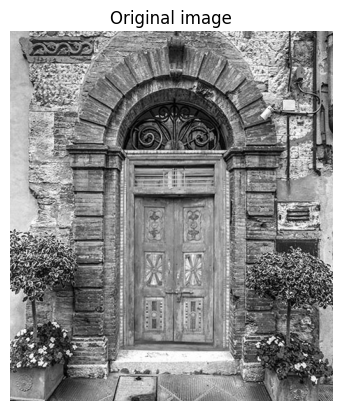

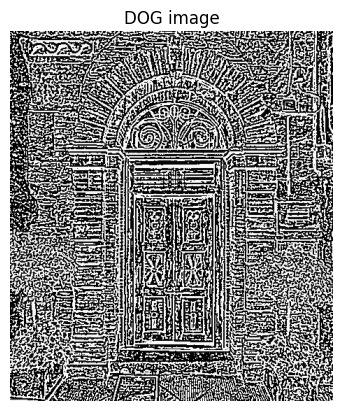

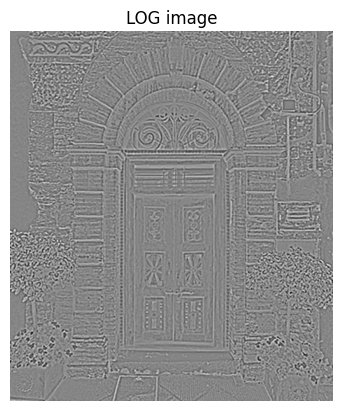

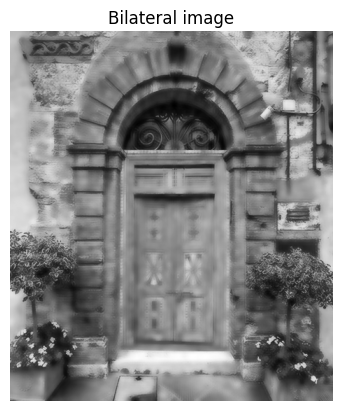

In [ ]:
# Import required libraries
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# Load image
img=cv.imread('images/door.jpg',0) # Use grayscale for filtering
plt.imshow(img,cmap='gray');plt.axis('off');plt.title('Original image');plt.show()

# TODO: Apply DoG
blur1=cv.GaussianBlur(img,(5,5),1)
blur2=cv.GaussianBlur(img,(5,5),2)
DOG=blur1-blur2
plt.imshow(DOG,cmap='gray');plt.axis('off');plt.title('DOG image');plt.show()

# TODO: Apply LoG
blur=cv.GaussianBlur(img,(5,5),1)
LOG=cv.Laplacian(blur,cv.CV_64F)
plt.imshow(LOG,cmap='gray');plt.axis('off'); plt.title("LOG image");plt.show()

# TODO: Apply bilateral (edge-preserving) filter
bi_filter=cv.bilateralFilter(img,d=10,sigmaColor=75,sigmaSpace=75)
plt.imshow(bi_filter,cmap='gray');plt.axis('off'); plt.title("Bilateral image");plt.show()
# Show all results for comparison

**Q1: What differences do you observe between DoG, LoG, and the edge-preserving filter?**

_Write your observations here._

In DoG → it basically subtracts two blurred photos (one blurred and one more blurred). This highlights the edges (they appear darker). In this photo, since it has a lot of edges and not many clear flat spots, most of it turned dark.
In LoG → it’s the same idea as DoG, but it uses the second derivative and the zero-crossing concept. Zero-crossing means that when the second derivative is zero, it’s a flat area (no change). Otherwise, if it’s strongly positive or negative, that indicates a change (an edge). So in LoG, the photo looks clearer, and it’s easier to see the edges and flat areas.
In Bilateral → it’s a preprocessing step. It simply combines two points that seem similar, making flat areas smooth. When two points are different, it keeps the difference sharp. So in the photo, most of the door looks smooth, but the edges stay sharp.

## 2. Keypoints & Descriptors: SIFT vs. ORB

**Task:**
- Detect and plot keypoints on `'sample.jpg'` using SIFT and ORB.
- Compare the number and distribution of detected keypoints.

**Background:**
- **Keypoints:** Distinctive image points (corners/blobs) useful for matching.
- **Descriptors:** Vectors that describe local patches around keypoints for comparison/matching.

---

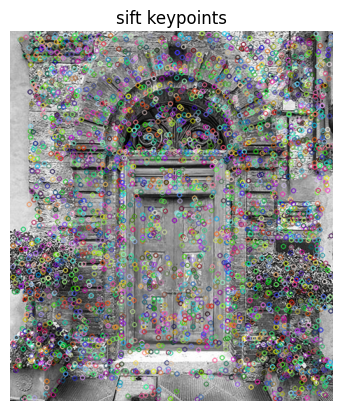

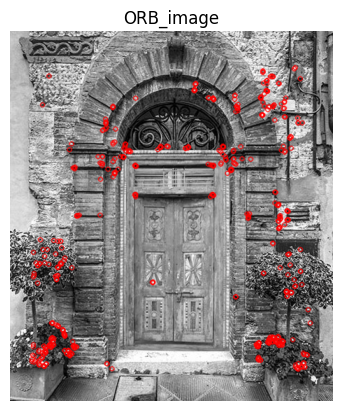

sift keypoints number 3765
orb keypoints number 500


In [8]:
# Detect and plot SIFT keypoints
sift=cv.SIFT_create()
sift_keypoints,descriptors=sift.detectAndCompute(img.astype(np.uint8), None)
img_sift=cv.drawKeypoints(img, sift_keypoints,None)
plt.imshow(img_sift,cmap='gray');plt.axis('off');plt.title('sift keypoints');plt.show()
# Detect and plot ORB keypoints
ORB=cv.ORB_create()
keypoints=ORB.detect(img)
keypoints,descriptors=ORB.compute(img,keypoints)
imageresult=cv.drawKeypoints(img, keypoints, None, color=(255,0,0), flags=0)
plt.imshow(imageresult,cmap='gray');plt.axis('off');plt.title('ORB_image');plt.show()
# TODO: Count and compare number of keypoints for SIFT and ORB
print("sift keypoints number",len(sift_keypoints))
print("orb keypoints number",len(keypoints))

**Q2: How do the number and distribution of keypoints differ between SIFT and ORB?**

_Write your answer here._

-> In SIFT it detects keypoints in images based on DoG subtraction. It finds out the keypoints by rotating and resizing images, seeing the same image in a lot of shapes, and then creates a descriptor consisting of 128 details. That is why SIFT is more accurate and powerful, but it is slow. So in the photo you will notice that SIFT has detected so many keypoints, more than ORB.
-> ORB is fast and easy. For me it is like an eye: first look when you see a photo — that is a corner, that is an edge, and so on. Then it adds an orientation to know the direction for each pixel and then compares that keypoint by a binary representation using BRIEF. So in our photo it didn’t show much info but just showed the clear things.

## 3. Feature Matching with Descriptors

**Task:**
- Load a second image (e.g., `'sample2.jpg'`).
- Detect keypoints/descriptors using SIFT or ORB in both images.
- Match the features between the images using BFMatcher or FLANN.
- Plot the top matches.

**Background:**
- **Feature matching** helps recognize objects/scenes or estimate image transformations.

---

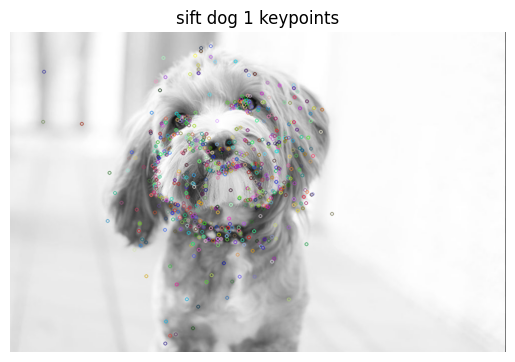

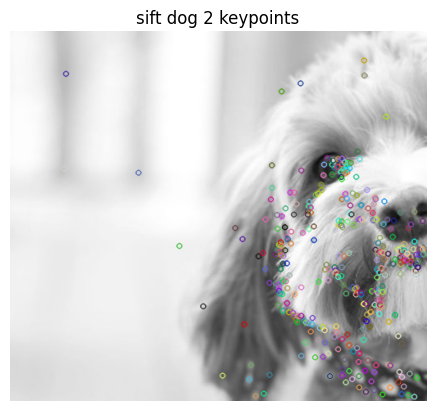

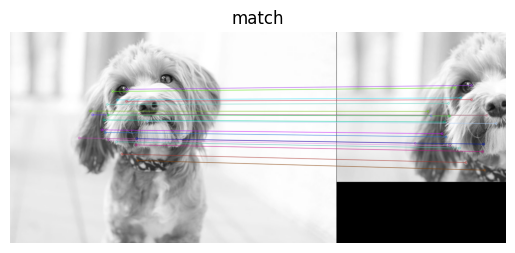

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# Load second image
img1=cv.imread('images/dogone.jpeg', 0)
img2=cv.imread('images/dogtwo.jpeg', 0)
# Detect SIFT keypoints/descriptors in both images
sift=cv.SIFT_create()
sift_keypoints1,descriptors1=sift.detectAndCompute(img1.astype(np.uint8), None)
img_sift1=cv.drawKeypoints(img1, sift_keypoints1,None)
plt.imshow(img_sift1,cmap='gray');plt.axis('off');plt.title('sift dog 1 keypoints');plt.show()
sift_keypoints2,descriptors2=sift.detectAndCompute(img2.astype(np.uint8), None)
img_sift2=cv.drawKeypoints(img2, sift_keypoints2,None)
plt.imshow(img_sift2,cmap='gray');plt.axis('off');plt.title('sift dog 2 keypoints');plt.show()
# BFMatcher with default params
bf=cv.BFMatcher()
matches=bf.match(descriptors1,descriptors2)
matches=sorted(matches,key=lambda x: x.distance)
# Draw matches
numberofmatches=20
img3=cv.drawMatches(img1,sift_keypoints1,img2,sift_keypoints2,matches[:numberofmatches],None,flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img3,cmap='gray');plt.axis('off');plt.title('match');plt.show()
# bonus TODO: Try with ORB or FLANN if you like

**Q3: What do you notice about the feature matches? Are there any mismatches or errors? How might you improve the matching process?**

_Write your answer here._

no i think it worked very well the keypoints we got from sift in the two images are matched well based on the Euclidean distance and the descriptors comparison .

**Bonus Task (Optional, for extra credit):**
- Try using different image preprocessing steps *before* edge detection or feature extraction.
    - For example:
        - Add noise to your image (e.g., Gaussian noise, salt-and-pepper noise).
        - Apply a sharpening filter to your image.
    - Then, run DoG, LoG, or any edge-preserving filter and observe the changes.
- **What to do:**
    - Show the results (images/plots) for at least one type of preprocessing + edge detection.
    - Briefly explain:
        - How does noise affect edge maps or keypoints?
        - Does sharpening make features easier or harder to detect/match?

**You can add your code and observations in the cells below.**


In [ ]:
# Write your code here

_What are your observations?_
write them here

## 4. Reflection (Optional)

- What was the most challenging or interesting part of this task for you?
- Any feedback or thoughts?

_Write your reflection here._